In [1]:
import sys
print(sys.executable)

C:\Users\Mansi\AppData\Local\Python\pythoncore-3.14-64\python.exe


In [9]:
import pandas as pd

df = pd.read_csv(r'D:\My Learnings\Supply Chain Analysis\Supply Chain Analysis for Beauty Products\supply_chain_data.csv')

In [19]:
df.head() #shows first five rows
df.shape #shows the total rows and columns in the table
df.columns #shows all the column names
df.info() #shows column names + data type + non-null count, all in one
df.describe() #shows mean/min/max/std for numeric columns only
df.dtypes #shows data type of each column, alone

<class 'pandas.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 24 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Product type             100 non-null    str    
 1   SKU                      100 non-null    str    
 2   Price                    100 non-null    float64
 3   Availability             100 non-null    int64  
 4   Number of products sold  100 non-null    int64  
 5   Revenue generated        100 non-null    float64
 6   Customer demographics    100 non-null    str    
 7   Stock levels             100 non-null    int64  
 8   Order Lead times         100 non-null    int64  
 9   Order quantities         100 non-null    int64  
 10  Shipping times           100 non-null    int64  
 11  Shipping carriers        100 non-null    str    
 12  Shipping costs           100 non-null    float64
 13  Supplier name            100 non-null    str    
 14  Location                 100 non-null 

Product type                   str
SKU                            str
Price                      float64
Availability                 int64
Number of products sold      int64
Revenue generated          float64
Customer demographics          str
Stock levels                 int64
Order Lead times             int64
Order quantities             int64
Shipping times               int64
Shipping carriers              str
Shipping costs             float64
Supplier name                  str
Location                       str
Supplier Lead time           int64
Production volumes           int64
Manufacturing lead time      int64
Manufacturing costs        float64
Inspection results             str
Defect rates               float64
Transportation modes           str
Routes                         str
Costs                      float64
dtype: object

In [12]:
df['Product type'] = df['Product type'].str.capitalize()
print(df)

   Product type    SKU      Price  Availability  Number of products sold  \
0      Haircare   SKU0  69.808006            55                      802   
1      Skincare   SKU1  14.843523            95                      736   
2      Haircare   SKU2  11.319683            34                        8   
3      Skincare   SKU3  61.163343            68                       83   
4      Skincare   SKU4   4.805496            26                      871   
..          ...    ...        ...           ...                      ...   
95     Haircare  SKU95  77.903927            65                      672   
96    Cosmetics  SKU96  24.423131            29                      324   
97     Haircare  SKU97   3.526111            56                       62   
98     Skincare  SKU98  19.754605            43                      913   
99     Haircare  SKU99  68.517833            17                      627   

    Revenue generated Customer demographics  Stock levels  Order Lead times  \
0       

In [25]:
# df['Price'] = df['Price'].round(2)
# df['Revenue generated'] = df['Revenue generated'].round(2)
# df['Manufacturing costs'] = df['Manufacturing costs'].round(2)
# df['Costs'] = df['Costs'].round(2)


# Round all currency columns to 2 decimal places
money_cols = ['Price', 'Revenue generated', 'Manufacturing costs', 'Shipping costs', 'Costs']
df[money_cols] = df[money_cols].round(2)
print(df)

   Product type    SKU  Price  Availability  Number of products sold  \
0      Haircare   SKU0  69.81            55                      802   
1      Skincare   SKU1  14.84            95                      736   
2      Haircare   SKU2  11.32            34                        8   
3      Skincare   SKU3  61.16            68                       83   
4      Skincare   SKU4   4.81            26                      871   
..          ...    ...    ...           ...                      ...   
95     Haircare  SKU95  77.90            65                      672   
96    Cosmetics  SKU96  24.42            29                      324   
97     Haircare  SKU97   3.53            56                       62   
98     Skincare  SKU98  19.75            43                      913   
99     Haircare  SKU99  68.52            17                      627   

    Revenue generated Customer demographics  Stock levels  Order Lead times  \
0             8662.00            Non-binary            5

In [24]:
df.isnull().sum() 
df.duplicated().sum()
df['Customer demographics'].unique()
df['Customer demographics'].value_counts()

Customer demographics
Unknown       31
Female        25
Non-binary    23
Male          21
Name: count, dtype: int64

In [34]:
#Renaming the columns
df = df.rename(columns={
    'Lead times': 'order_lead_time_days',
    'Lead time': 'supplier_lead_time_days'
})          

#EDA (Exploratory Data Analysis)

In [35]:
#1.Revenue & sales patterns by product type - tells you which category actually drives the business.
df.groupby('Product type')['Revenue generated'].mean().sort_values(ascending=False)
df.groupby('Product type')['Number of products sold'].sum().sort_values(ascending=False)

Product type
Skincare     20731
Haircare     13611
Cosmetics    11757
Name: Number of products sold, dtype: int64

In [44]:
#2. Supplier comparison — defect rate, lead time, cost
df = df.rename(columns={
    'Order Lead times': 'order_lead_time_days',
    'Supplier Lead time': 'supplier_lead_time_days'
})


In [45]:
supplier_analysis = (
    df.groupby('Supplier name')
      .agg({
          'Defect rates':'mean',
          'supplier_lead_time_days':'mean',
          'Costs':'mean',
          'Revenue generated':'sum'
      })
      .round(2)
      .sort_values('Revenue generated', ascending=False)
)

supplier_analysis

,Defect rates,supplier_lead_time_days,Costs,Revenue generated
Supplier name,,,,
Supplier 1,1.80,14.78,574.85,157528.98
Supplier 2,2.36,18.55,515.03,125467.45
Supplier 5,2.67,18.06,536.02,110343.48
Supplier 3,2.47,20.13,468.80,97795.98
Supplier 4,2.34,15.22,521.81,86468.97


In [49]:
#3. Carrier and transport mode performance
df.groupby('Shipping carriers')[['Shipping costs', 'Shipping times']].mean().round(2)

df.groupby('Transportation modes')[['Shipping costs', 'Shipping times']].mean().round(2)


,Shipping costs,Shipping times
Transportation modes,,
Air,6.02,5.12
Rail,5.47,6.57
Road,5.54,4.72
Sea,4.97,7.12


In [50]:
#Inspection/quality patterns-cost vs speed tradeoff across carriers — classic supply chain insight.
df['Inspection results'].value_counts()

Inspection results
Pending    41
Fail       36
Pass       23
Name: count, dtype: int64

In [52]:
df.groupby('Supplier name')['Inspection results'].value_counts(normalize=True).unstack(fill_value=0).round(2)

Inspection results,Fail,Pass,Pending
Supplier name,,,
Supplier 1,0.22,0.48,0.30
Supplier 2,0.36,0.23,0.41
Supplier 3,0.20,0.13,0.67
Supplier 4,0.67,0.00,0.33
Supplier 5,0.39,0.17,0.44


In [53]:
#5. Correlation check — do any numeric columns move together?
df[['Price','Revenue generated','Defect rates','Shipping costs','Costs']].corr().round(2)

,Price,Revenue generated,Defect rates,Shipping costs,Costs
Price,1.00,0.04,-0.15,0.06,0.09
Revenue generated,0.04,1.00,-0.13,-0.07,0.03
Defect rates,-0.15,-0.13,1.00,0.08,0.03
Shipping costs,0.06,-0.07,0.08,1.00,0.05
Costs,0.09,0.03,0.03,0.05,1.00


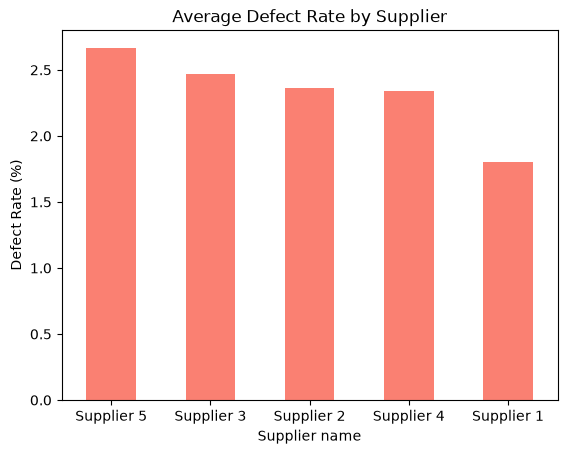

In [54]:
import matplotlib.pyplot as plt

df.groupby('Supplier name')['Defect rates'].mean().sort_values(ascending=False).plot(kind='bar', color='salmon')
plt.title('Average Defect Rate by Supplier')
plt.ylabel('Defect Rate (%)')
plt.xticks(rotation=0)
plt.show()